In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from scipy import fft

%config InlineBackend.figure_formats = ['svg']
%matplotlib inline

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

# Sine and Cosine

Sine and cosine are identical in the magnitude spectrum. Both show only two delta impulses - one at the negative and one at the positive frequency of the sine or cosine. 
Since the two functions differ only in phase, their phase spectrum is different.

$$
\begin{eqnarray}
\cos(\omega t) &~&  \mapsto &~& \pi \left[\delta(\omega -\omega_0 ) + \delta(\omega +\omega_0 ) \right] \\
\cos(\omega t) &~&  \mapsto &~& \frac{\pi}{j} \left[\delta(\omega -\omega_0 ) - \delta(\omega +\omega_0 ) \right] \\
\end{eqnarray}
$$




----

## DFT of a Sine Wave

In the field of musical signal processing, the sine wave (respectively the cosine wave) are the basic elements of complex sounds. They can be used to model and synthesize any periodic signal. Hence, the frequency domain representation of these harmonic functions is fundamental to the understanding of many algorithms for analysis and synthesis.

In many visualizations, a sinusoidal spectrum is shown as a single peak at the oscillation's frequency. However, this is only true for a signal of infinite length.
When viewed closely, these peaks are smeared and accompanied by several so called *side lobes*. 
This is the so called *spectral leakage* effect.
The following example derives these characteristics,
based on a $1024$ sample sine wave with a frequency of $f_0 = 100\ \mathrm{Hz}$ at a sampling rate of $f_s = 16\ \mathrm{kHz}$:

For calculating the DFT of sinusoidal signals, it makes sense to express them in the complex notation through Euler's formula:

$$
\sin \left(2 \pi f_0 \frac{n}{fs} \right) = \frac{1}{2j} \left( e^{j 2 \pi f_0 \frac{n}{fs} } -e^{-j2 \pi f_0 \frac{n}{fs}} \right) \\
$$


The DFT of the sine wave thus extends to:

$$
X[k] =  \sum\limits_{n=0}^{N-1} \frac{1}{2j} \left(e^{j 2 \pi \frac{f_0}{fs} n} -e^{-j2 \pi \frac{f_0}{fs} n} \right) e^{-j 2 \pi k \frac{n}{N}} \\
$$

Solving:

$$
\begin{eqnarray}
X[k] & = & \frac{1}{2j} \sum\limits_{i=0}^{N-1} 
e^{- j 2 \pi k \frac{n}{N} + j 2 \pi \frac{f_0}{fs} n } 
- e^{- j 2 \pi k \frac{n}{N} - j 2 \pi\frac{f_0}{fs} n} \\
%
%
& = & \frac{1}{2j} \sum\limits_{i=0}^{N-1} 
e^{- j 2 \pi     (  \frac{k}{N} - \frac{f_0}{fs}    ) n }
- e^{- j 2 \pi    (   \frac{k}{N} + \frac{f_0}{fs}) n} \\
%
%
& = & \frac{1}{2j} \sum\limits_{i=0}^{N-1} 
e^{- j 2 \pi     (  \frac{k}{N} - \frac{f_0}{fs}    ) n }
- \frac{1}{2j} \sum\limits_{i=0}^{N-1}  
e^{- j 2 \pi    (   \frac{k}{N} + \frac{f_0}{fs}) n} \\
%
%
\end{eqnarray}
$$



**Geometric Series**

Using the geometric series formula (with acknowledgements to [1](#fn1 "footnote 1"))


$$
\sum\limits_{n=0}^{N-1} a^n =  \frac{1-a^{N}}{1-a} 
$$

the above equation results in:


$$
X[k] = \frac{1}{2j} \frac{1-e^{-j 2 \pi \left( \frac{k}{N} - \frac{f_0}{fs} \right) N}}{1-e^{-j 2 \pi \left( \frac{k}{N} - \frac{f_0}{fs} \right)}}
%
+  \frac{1}{2j} \frac{1-e^{-j 2 \pi (\left( \frac{k}{N} + \frac{f_0}{fs} \right)) N}}{1-e^{-j 2 \pi \left( \frac{k}{N} + \frac{f_0}{fs} \right)}}
$$

[<sup id="fn1">1</sup>](#fn1-back) http://www.eecs.umich.edu/courses/eecs452/overview.html


**Factoring out**

The above equation features the following term:

$$
E = \frac{1-e^{-j \Lambda N}}{1-e^{-j \Lambda}}
$$

After factoring out the term  $\frac{e^{-j \Lambda \frac{N}{2}}}{e^{-j \frac{\Lambda}{2}}}$
we can solve further, using Euler's formula:

$$
\begin{eqnarray}
E & = & \frac{e^{-j \Lambda \frac{N}{2}}} 
{e^{-j \frac{\Lambda}{2}}} \cdot
\frac{e^{j \Lambda \frac{N}{2}} - e^{-j \Lambda 
\frac{N}{2}}}{e^{j \frac{\Lambda}{2}}  -  e^{-j \frac{\Lambda}{2}}} \\
%
%
& = & e^{-j \Lambda    \frac{N+1}{2} } \underbrace{\frac{\sin(\Lambda \frac{N}{2} )}{\sin(\frac{\Lambda}{2})}}_{\text{Dirichlet function}}
\end{eqnarray}
$$

As the plot below shows, the term is characterized by a Dirichlet function, which is related to the ``sinc`` function. Inserting

$$
\begin{eqnarray}
\Lambda(-f_0) & = & 2 \pi \left( \frac{k}{N} - \frac{f_0}{fs} \right) \\
\Lambda(+f_0) & = & 2 \pi \left( \frac{k}{N} + \frac{f_0}{fs} \right) \\
\end{eqnarray}
$$

we get the following result for the spectrum of the sinusoid:


$$
\begin{eqnarray}
X [k] & = & \frac{1}{2j}
\left(
 e^{-j \Lambda(-f_0)  \frac{N+1}{2} } \frac{\sin(\Lambda(-f_0)  \frac{N}{2} )}{\sin(\frac{\Lambda(-f_0) }{2})}
%
+ e^{-j \Lambda(+f_0)  \frac{N+1}{2} } \frac{\sin(\Lambda(+f_0) \frac{N}{2} )}{\sin(\frac{\Lambda(+f_0)}{2})}
\right)
\end{eqnarray}
$$

According to the shift theorem, the above equation holds two components - one cenered at $f_0$,
another centered at $-f_0$, each with a main lobe and an infinite number of sidelobes:



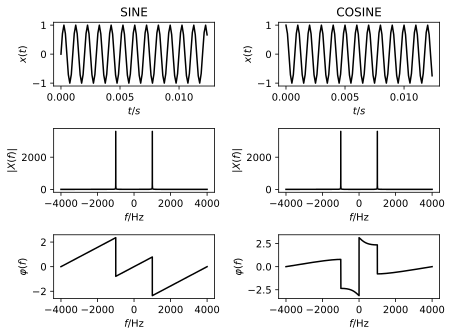

In [10]:
fs = 8000
N  = fs
t = np.linspace(0,1,N)

f  = np.linspace(-fs/2,fs/2,N)
k  = np.linspace(0,N-1,N)

f0 = f[5000]

x  = np.sin(2*np.pi*(f0)*t)
X  = fft.fftshift(fft.fft(x))
x2  = np.cos(2*np.pi*(f0)*t)
X2  = fft.fftshift(fft.fft(x2))



fig = plt.figure()

ax1 = plt.subplot(3,2,1)
ax1.set_title('SINE')
ax1.plot(t[0:100],x[0:100],'k')
ax1.set_xlabel("$t/s$");
ax1.set_ylabel("$x(t)$");

ax2 = plt.subplot(3,2,3)
ax2.plot(f,abs(X),'k')
ax2.set_xlabel("$f/\mathrm{Hz}$");
ax2.set_ylabel("$|X(f)|$");

ax3 = plt.subplot(3,2,5)
ax3.plot(f,np.angle(X),'k')
ax3.set_xlabel("$f/\mathrm{Hz}$");
ax3.set_ylabel("$\\varphi(f)$");


ax4 = plt.subplot(3,2,2)
ax4.set_title('COSINE')
ax4.plot(t[0:100],x2[0:100],'k')
ax4.set_xlabel("$t/s$");
ax4.set_ylabel("$x(t)$");

ax5 = plt.subplot(3,2,4)
ax5.plot(f,abs(X2),'k')
ax5.set_xlabel("$f/\mathrm{Hz}$");
ax5.set_ylabel("$|X(f)|$");

ax6 = plt.subplot(3,2,6)
ax6.plot(f,np.angle(X2),'k')
ax6.set_xlabel("$f/\mathrm{Hz}$");
ax6.set_ylabel("$\\varphi(f)$");

fig.tight_layout(pad=1)


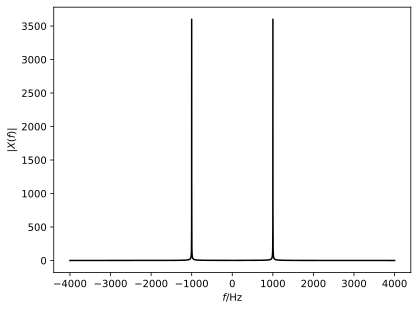

In [12]:
fs = 8000
N  = fs
t = np.linspace(0,1,N)

f  = np.linspace(-fs/2,fs/2,N)
k  = np.linspace(0,N-1,N)

f0 = f[5000]

x  = np.sin(2*np.pi*(f0)*t)
X  = fft.fftshift(fft.fft(x))
x2  = np.cos(2*np.pi*(f0)*t)
X2  = fft.fftshift(fft.fft(x2))


fig = plt.figure()

 

ax2 = plt.subplot(1,1,1)
ax2.plot(f,abs(X),'k')
ax2.set_xlabel("$f/\mathrm{Hz}$");
ax2.set_ylabel("$|X(f)|$");






<div class="alert alert-block alert-info">
    <b>Exercise:</b> Calculate the DFT spectrum of a cosine and compare it to the sine example above. What do the different outcomes show?
</div>

---
